# Deep Learning Exoplanet Vetting from Time-Series Photometry

A 1D CNN-based exoplanet vetting system inspired by
Shallue & Vanderburg (2018) AstroNet.

## Objectives

1. Preprocess Kepler light curves
2. Build a baseline 1D CNN
3. Build an AstroNet-style dual-input CNN
4. Estimate prediction uncertainty using Monte Carlo Dropout
5. Visualize model decisions using saliency / Grad-CAM
6. Evaluate classification and calibration
7. Analyze representative predictions

**1. Environment Setup**

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


TensorFlow: 2.20.0
NumPy: 2.1.3
Pandas: 2.2.3


In [20]:
gpu = tf.config.list_physical_devices("GPU")

if gpu:
  print("GPU available:", gpu)
else:
  print("WARNING: No GPU detected")

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**2. Load the dataset**

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**3. Verify your AstroNet files**

In [11]:
import os

ASTRONET_DIR = "/content/drive/MyDrive/AstroNet"

print(os.listdir(ASTRONET_DIR))

['val-00000-of-00001', 'train-00007-of-00008', 'train-00006-of-00008', 'train-00004-of-00008', 'train-00005-of-00008', 'train-00001-of-00008', 'train-00002-of-00008', 'train-00003-of-00008', 'test-00000-of-00001', 'train-00000-of-00008']


**4. Verify the number of files**

In [10]:
import os

ASTRONET_DIR = "/content/drive/MyDrive"

files = os.listdir(ASTRONET_DIR)

train_files = sorted(
    f for f in files if f.startswith("train-")
)

val_files = sorted(
    f for f in files if f.startswith("val-")
)

test_files = sorted(
    f for f in files if f.startswith("test-")
)

print("Training files:", len(train_files))
print("Validation files:", len(val_files))
print("Test files:", len(test_files))

print("\nTraining files:")
print(train_files)

print("\nValidation files:")
print(val_files)

print("\nTest files:")
print(test_files)

Training files: 8
Validation files: 1
Test files: 1

Training files:
['train-00000-of-00008', 'train-00001-of-00008', 'train-00002-of-00008', 'train-00003-of-00008', 'train-00004-of-00008', 'train-00005-of-00008', 'train-00006-of-00008', 'train-00007-of-00008']

Validation files:
['val-00000-of-00001']

Test files:
['test-00000-of-00001']


**5. Verify Kaggle dataset**

In [12]:
import tensorflow as tf
import os

train_path = os.path.join(
    ASTRONET_DIR,
    "train-00000-of-00008"
)

raw_dataset = tf.data.TFRecordDataset(train_path)

print(raw_dataset)

<TFRecordDatasetV2 element_spec=TensorSpec(shape=(), dtype=tf.string, name=None)>


**6. Read one example**




In [13]:
raw_example = next(iter(raw_dataset))

print(type(raw_example))
print(raw_example.shape)

<class 'tensorflow.python.framework.ops.EagerTensor'>
()


**7. Parse the example**

In [15]:
example = tf.train.Example()

example.ParseFromString(
    raw_example.numpy()
)

print(example)

features {
  feature {
    key: "tce_time0bk"
    value {
      float_list {
        value: 179.098
      }
    }
  }
  feature {
    key: "tce_prad"
    value {
      float_list {
        value: 3.005
      }
    }
  }
  feature {
    key: "tce_plnt_num"
    value {
      int64_list {
        value: 2
      }
    }
  }
  feature {
    key: "tce_period"
    value {
      float_list {
        value: 62.3026
      }
    }
  }
  feature {
    key: "tce_model_snr"
    value {
      float_list {
        value: 32.67
      }
    }
  }
  feature {
    key: "tce_max_mult_ev"
    value {
      float_list {
        value: 33.72
      }
    }
  }
  feature {
    key: "tce_impact"
    value {
      float_list {
        value: 0.7147
      }
    }
  }
  feature {
    key: "tce_duration"
    value {
      float_list {
        value: 0.312083334
      }
    }
  }
  feature {
    key: "tce_depth"
    value {
      float_list {
        value: 832.3
      }
    }
  }
  feature {
    key: "spline_bkspace

**8. See what features exist**

In [16]:
features = example.features.feature

print("Number of features:", len(features))

print("\nFeatures:")
for name in features:
    print(name)

Number of features: 15

Features:
tce_depth
global_view
av_pred_class
tce_time0bk
tce_plnt_num
local_view
tce_duration
av_training_set
spline_bkspace
tce_period
tce_model_snr
kepid
tce_impact
tce_max_mult_ev
tce_prad


**9. Extract Global and Local views**

In [17]:
global_view = np.array(
    features["global_view"].float_list.value,
    dtype=np.float32
)

local_view = np.array(
    features["local_view"].float_list.value,
    dtype=np.float32
)

print("Global view shape:", global_view.shape)
print("Local view shape :", local_view.shape)

Global view shape: (2001,)
Local view shape : (201,)


**10. Plot them**

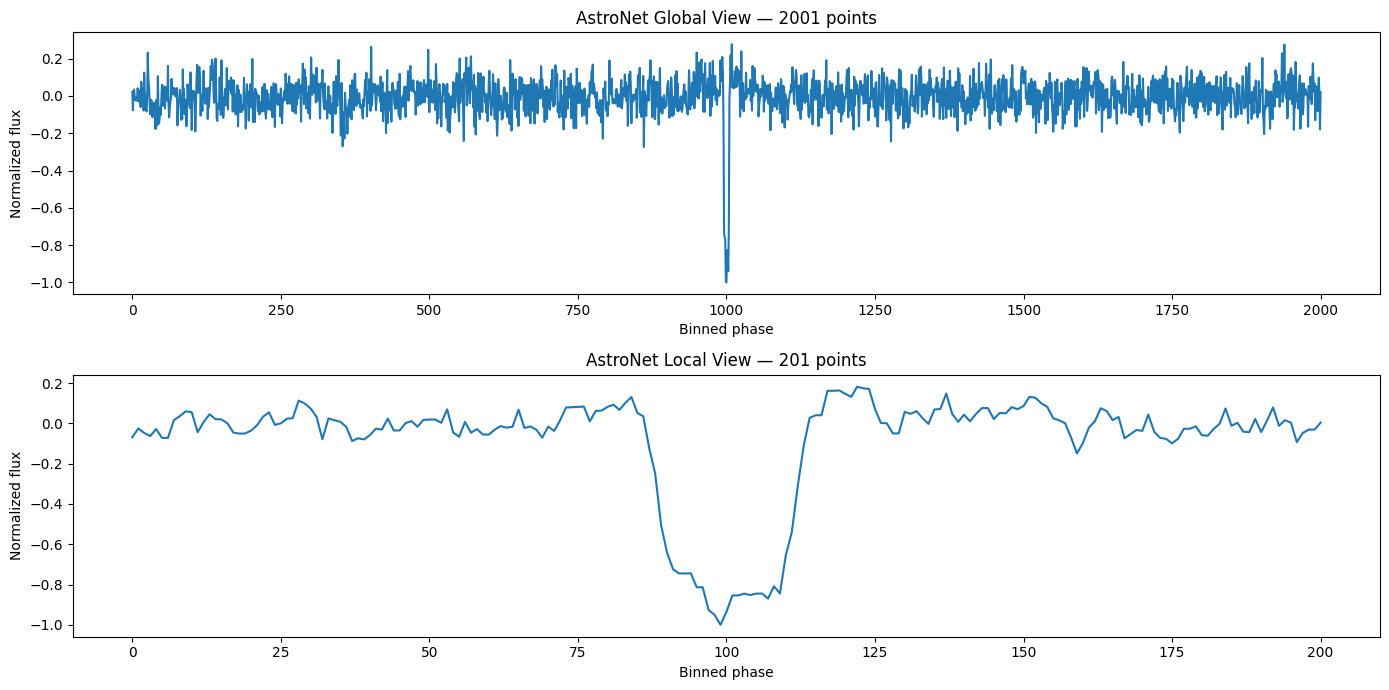

In [18]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7)
)

axes[0].plot(global_view)
axes[0].set_title("AstroNet Global View — 2001 points")
axes[0].set_xlabel("Binned phase")
axes[0].set_ylabel("Normalized flux")

axes[1].plot(local_view)
axes[1].set_title("AstroNet Local View — 201 points")
axes[1].set_xlabel("Binned phase")
axes[1].set_ylabel("Normalized flux")

plt.tight_layout()
plt.show()

**11. Inspect the label-related features**

In [21]:
# Print all feature names again
for name in features.keys():
    print(name)

tce_depth
global_view
av_pred_class
tce_time0bk
tce_plnt_num
local_view
tce_duration
av_training_set
spline_bkspace
tce_period
tce_model_snr
kepid
tce_impact
tce_max_mult_ev
tce_prad


**12. Check all possible class values**

In [22]:
# Check the labels in all training files

labels = []

for filename in train_files:
    path = os.path.join(ASTRONET_DIR, filename)

    dataset = tf.data.TFRecordDataset(path)

    for raw in dataset:
        ex = tf.train.Example()
        ex.ParseFromString(raw.numpy())

        label = ex.features.feature["av_pred_class"].bytes_list.value[0].decode()
        labels.append(label)

# Count each class
from collections import Counter

print("Total examples:", len(labels))
print("Class counts:")
print(Counter(labels))

Total examples: 12589
Class counts:
Counter({'AFP': 7601, 'PC': 2886, 'NTP': 2102})


**13. Create our binary-label rule**

In [26]:
def convert_label(label):
    """
    Convert AstroNet labels into binary labels.

    PC  -> 1 (planet)
    AFP -> 0 (false positive)
    NTP -> 0 (false positive)
    """

    if label == "PC":
        return 1

    elif label in ["AFP", "NTP"]:
        return 0

    else:
        return None

In [27]:
print("PC  →", convert_label("PC"))
print("AFP →", convert_label("AFP"))
print("NTP →", convert_label("NTP"))

PC  → 1
AFP → 0
NTP → 0


In [29]:
import os

astro_folder = "/content/drive/MyDrive/AstroNet"

train_files = [
    os.path.join(astro_folder, f"train-0000{i}-of-00008")
    for i in range(8)
]

print("Training files:")
for f in train_files:
    print(f, "→", os.path.exists(f))

Training files:
/content/drive/MyDrive/AstroNet/train-00000-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00001-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00002-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00003-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00004-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00005-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00006-of-00008 → True
/content/drive/MyDrive/AstroNet/train-00007-of-00008 → True


In [30]:
from collections import Counter

label_counts = Counter()

for file_path in train_files:
    dataset = tf.data.TFRecordDataset(file_path)

    for raw_record in dataset:
        example = tf.train.Example()
        example.ParseFromString(raw_record.numpy())

        label = example.features.feature["av_training_set"].bytes_list.value[0].decode()

        label_counts[label] += 1

print("av_training_set label counts:")
for label, count in label_counts.items():
    print(label, ":", count)

av_training_set label counts:
PC : 2885
AFP : 7643
NTP : 2061


**14. Build the TensorFlow input pipeline**

In [31]:
# Feature structure inside each TFRecord example
feature_description = {
    "global_view": tf.io.FixedLenFeature([2001], tf.float32),
    "local_view": tf.io.FixedLenFeature([201], tf.float32),
    "av_training_set": tf.io.FixedLenFeature([], tf.string),
}


def parse_example(serialized_example):
    # Read one TFRecord example
    parsed = tf.io.parse_single_example(
        serialized_example,
        feature_description
    )

    # Read the original AstroNet label
    original_label = parsed["av_training_set"]

    # Convert labels into binary form
    label = tf.where(
        tf.equal(original_label, b"PC"),
        1,
        0
    )

    # Check that the label is known
    known_label = tf.logical_or(
        tf.equal(original_label, b"PC"),
        tf.logical_or(
            tf.equal(original_label, b"AFP"),
            tf.equal(original_label, b"NTP")
        )
    )

    # Add the channel dimension for Conv1D
    global_view = tf.expand_dims(parsed["global_view"], axis=-1)
    local_view = tf.expand_dims(parsed["local_view"], axis=-1)

    return (global_view, local_view), tf.cast(label, tf.int32), known_label


# Read all 8 training TFRecord shards
train_dataset = tf.data.TFRecordDataset(
    train_files,
    num_parallel_reads=tf.data.AUTOTUNE
)

# Parse every example
train_dataset = train_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels, if any
train_dataset = train_dataset.filter(
    lambda inputs, label, known: known
)

# Remove the temporary "known" value
train_dataset = train_dataset.map(
    lambda inputs, label, known: (inputs, label),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Shuffle examples
train_dataset = train_dataset.shuffle(
    buffer_size=5000
)

# Group examples into batches
train_dataset = train_dataset.batch(64)

# Prepare the next batch while the model is training
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

print("Training pipeline created successfully.")

Training pipeline created successfully.


**15. Inspect one training batch**

In [32]:
# Take one batch from the training dataset
(inputs, labels) = next(iter(train_dataset))

# Separate global and local views
global_batch, local_batch = inputs

print("Global batch shape:", global_batch.shape)
print("Local batch shape :", local_batch.shape)
print("Labels shape      :", labels.shape)

print("\nFirst 10 labels:")
print(labels[:10].numpy())

print("\nUnique labels in batch:")
print(tf.unique(labels).y.numpy())

Global batch shape: (64, 2001, 1)
Local batch shape : (64, 201, 1)
Labels shape      : (64,)

First 10 labels:
[0 0 0 1 0 1 0 0 0 0]

Unique labels in batch:
[0 1]


**16. Baseline 1D CNN**

In [33]:
# Create the input for the global light curve
global_input = tf.keras.Input(
    shape=(2001, 1),
    name="global_input"
)

# First convolution block
x = tf.keras.layers.Conv1D(
    filters=16,
    kernel_size=5,
    activation="relu"
)(global_input)

x = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(x)

# Second convolution block
x = tf.keras.layers.Conv1D(
    filters=32,
    kernel_size=5,
    activation="relu"
)(x)

x = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(x)

# Third convolution block
x = tf.keras.layers.Conv1D(
    filters=64,
    kernel_size=5,
    activation="relu"
)(x)

x = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(x)

# Convert feature maps into one vector
x = tf.keras.layers.Flatten()(x)

# Fully connected layer
x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

# Output: probability of being a planet
output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="planet_probability"
)(x)

# Create the model
baseline_model = tf.keras.Model(
    inputs=global_input,
    outputs=output,
    name="Baseline_1D_CNN"
)

baseline_model.summary()

Model: "Baseline_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ global_input (InputLayer)       │ (None, 2001, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 1997, 16)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 997, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 993, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 495, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 491, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 244, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       999,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ planet_probability (Dense)      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,012,545 (3.86 MB)

 Trainable params: 1,012,545 (3.86 MB)

 Non-trainable params: 0 (0.00 B)

**17. Compile the baseline model**

In [34]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("Baseline model compiled successfully.")

Baseline model compiled successfully.


**18. Calculate class weights**

In [35]:
# Number of examples in each class
num_planets = 2885
num_non_planets = 9704
total = num_planets + num_non_planets

# Calculate balanced class weights
weight_for_0 = total / (2 * num_non_planets)
weight_for_1 = total / (2 * num_planets)

class_weights = {
    0: weight_for_0,
    1: weight_for_1
}

print("Class weights:")
print("Non-planet (0):", weight_for_0)
print("Planet (1):", weight_for_1)

Class weights:
Non-planet (0): 0.6486500412201154
Planet (1): 2.1818024263431544


**19 — Train the baseline CNN**

In [36]:
# Keep only the global view for the baseline model
baseline_train_dataset = train_dataset.map(
    lambda inputs, label: (inputs[0], label),
    num_parallel_calls=tf.data.AUTOTUNE
)

print("Baseline training dataset ready.")

Baseline training dataset ready.


**20. Prepare validation data + train baseline**

In [37]:
# Path to the validation TFRecord
val_files = [
    os.path.join(astro_folder, "val-00000-of-00001")
]

# Load validation examples
val_dataset = tf.data.TFRecordDataset(val_files)

# Parse the examples using our existing parser
val_dataset = val_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels
val_dataset = val_dataset.filter(
    lambda inputs, label, known: known
)

# Keep only the global view for the baseline
val_dataset = val_dataset.map(
    lambda inputs, label, known: (inputs[0], label),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Create batches
val_dataset = val_dataset.batch(64)

# Prefetch for faster validation
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)


# Train the baseline CNN
history = baseline_model.fit(
    baseline_train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
    197/Unknown 16s 34ms/step - accuracy: 0.8192 - auc: 0.8761 - loss: 0.4258 - precision: 0.5704 - recall: 0.7417

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.8646 - auc: 0.9423 - loss: 0.3040 - precision: 0.6524 - recall: 0.8763 - val_accuracy: 0.9123 - val_auc: 0.9671 - val_loss: 0.2294 - val_precision: 0.7343 - val_recall: 0.9577
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9130 - auc: 0.9727 - loss: 0.1983 - precision: 0.7398 - recall: 0.9570 - val_accuracy: 0.8895 - val_auc: 0.9711 - val_loss: 0.2705 - val_precision: 0.6750 - val_recall: 0.9831
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9223 - auc: 0.9791 - loss: 0.1714 - precision: 0.7607 - recall: 0.9643 - val_accuracy: 0.9187 - val_auc: 0.9684 - val_loss: 0.1996 - val_precision: 0.7609 - val_recall: 0.9324
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9323 - auc: 0.9824 - loss: 0.1528 - precision: 0.7855 - recall: 0.9695 - val_accuracy: 0.9212 - val_auc: 0.9729 - val_loss: 0.2367 - val_precision: 0.7561 - val_recall: 0.9606
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━

**21. Check validation-set size**

In [38]:
# Count validation examples
val_count = 0

for file_path in val_files:
    dataset = tf.data.TFRecordDataset(file_path)

    for raw_record in dataset:
        val_count += 1

print("Validation examples:", val_count)

# Calculate number of batches
val_steps = (val_count + 63) // 64

print("Validation batches:", val_steps)

Validation examples: 1574
Validation batches: 25


**22. Fix the dataset exhaustion issue**

In [39]:
# Number of training batches
train_steps = 197

# Rebuild training dataset so it repeats continuously
baseline_train_dataset = baseline_train_dataset.repeat()

# Rebuild validation dataset so it repeats continuously
val_dataset = val_dataset.repeat()

print("Training steps per epoch:", train_steps)
print("Validation steps:", val_steps)

Training steps per epoch: 197
Validation steps: 25


**23. Prepare the test dataset**

In [40]:
# Path to the test TFRecord
test_files = [
    os.path.join(astro_folder, "test-00000-of-00001")
]

# Load the test TFRecord
test_dataset = tf.data.TFRecordDataset(test_files)

# Parse each example
test_dataset = test_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels
test_dataset = test_dataset.filter(
    lambda inputs, label, known: known
)

# Keep only the global view for the baseline
test_dataset = test_dataset.map(
    lambda inputs, label, known: (inputs[0], label),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch the test data
test_dataset = test_dataset.batch(64)

# Prefetch for faster evaluation
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Test dataset prepared successfully.")

Test dataset prepared successfully.


**24. Count test examples**

In [41]:
# Count test examples
test_count = 0

for file_path in test_files:
    dataset = tf.data.TFRecordDataset(file_path)

    for raw_record in dataset:
        test_count += 1

print("Test examples:", test_count)

# Calculate number of test batches
test_steps = (test_count + 63) // 64

print("Test batches:", test_steps)

Test examples: 1574
Test batches: 25


**25. Evaluate the baseline CNN**

In [42]:
# Evaluate the trained baseline model on the test set
test_results = baseline_model.evaluate(
    test_dataset,
    steps=test_steps,
    verbose=1
)

# Print the results clearly
for name, value in zip(baseline_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9161 - auc: 0.9783 - loss: 0.2401 - precision: 0.7446 - recall: 0.9639
loss: 0.2401
compile_metrics: 0.9161


**26. Get complete test metrics**

In [43]:
print("Complete baseline test results:")

for i, value in enumerate(test_results):
    print(i, "→", value)

Complete baseline test results:
0 → 0.24009530246257782
1 → 0.9161372184753418
2 → 0.7446351647377014
3 → 0.9638888835906982
4 → 0.9782730937004089


**27. Generate test predictions**

In [44]:
# Store the true labels
y_true = []

# Store the predicted probabilities
y_prob = []

# Go through the test dataset
for x_batch, y_batch in test_dataset:
    # Predict probability of being a planet
    predictions = baseline_model.predict(
        x_batch,
        verbose=0
    )

    # Save true labels
    y_true.extend(y_batch.numpy())

    # Save predicted probabilities
    y_prob.extend(predictions.flatten())

# Convert to NumPy arrays
y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Convert probabilities into binary predictions
y_pred = (y_prob >= 0.5).astype(int)

print("True labels:", y_true.shape)
print("Predicted probabilities:", y_prob.shape)
print("Predicted labels:", y_pred.shape)

True labels: (1574,)
Predicted probabilities: (1574,)
Predicted labels: (1574,)


**28. Confusion Matrix + Classification Report**

F1-score: 0.8402

Classification Report:
              precision    recall  f1-score   support

  Non-planet       0.99      0.90      0.94      1214
      Planet       0.74      0.96      0.84       360

    accuracy                           0.92      1574
   macro avg       0.87      0.93      0.89      1574
weighted avg       0.93      0.92      0.92      1574


Confusion Matrix:
[[1095  119]
 [  13  347]]


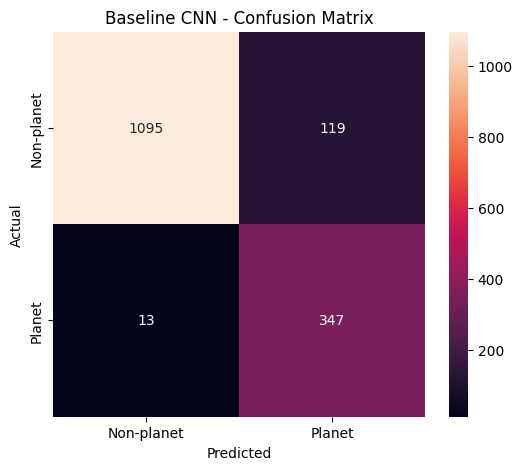

In [45]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate F1-score
f1 = f1_score(y_true, y_pred)

print("F1-score:", round(f1, 4))

# Print detailed classification report
print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Non-planet", "Planet"]
    )
)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-planet", "Planet"],
    yticklabels=["Non-planet", "Planet"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline CNN - Confusion Matrix")
plt.show()

**29. Plot the ROC curve**

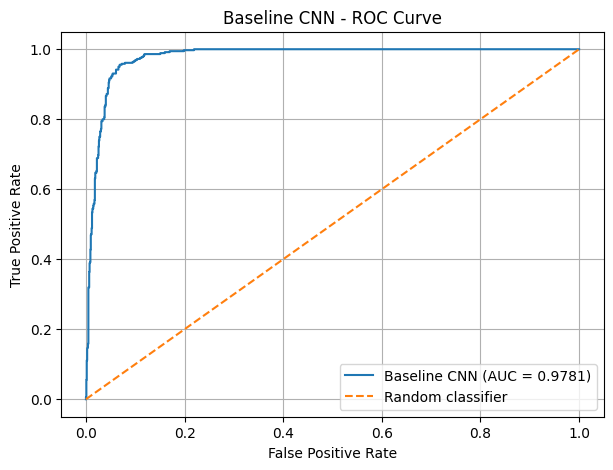

ROC-AUC: 0.9781


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

# Calculate ROC-AUC
roc_auc = roc_auc_score(
    y_true,
    y_prob
)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Baseline CNN (AUC = {roc_auc:.4f})"
)

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Baseline CNN - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("ROC-AUC:", round(roc_auc, 4))

**30. Build the AstroNet Global Branch**

In [47]:
# Global-view input
global_input = tf.keras.Input(
    shape=(2001, 1),
    name="global_input"
)

# Global CNN branch
g = tf.keras.layers.Conv1D(
    filters=16,
    kernel_size=5,
    activation="relu"
)(global_input)

g = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(g)

g = tf.keras.layers.Conv1D(
    filters=32,
    kernel_size=5,
    activation="relu"
)(g)

g = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(g)

g = tf.keras.layers.Conv1D(
    filters=64,
    kernel_size=5,
    activation="relu"
)(g)

g = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(g)

g = tf.keras.layers.Conv1D(
    filters=128,
    kernel_size=5,
    activation="relu"
)(g)

g = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(g)

g = tf.keras.layers.Conv1D(
    filters=256,
    kernel_size=5,
    activation="relu"
)(g)

g = tf.keras.layers.MaxPooling1D(
    pool_size=5,
    strides=2
)(g)

# Convert global feature maps into one vector
g = tf.keras.layers.Flatten(
    name="global_flatten"
)(g)

print("Global branch created.")
print("Global feature shape:", g.shape)

Global branch created.
Global feature shape: (None, 14080)


**31. Build the Local CNN branch**

In [48]:
# Local-view input
local_input = tf.keras.Input(
    shape=(201, 1),
    name="local_input"
)

# Local CNN branch
l = tf.keras.layers.Conv1D(
    filters=16,
    kernel_size=5,
    activation="relu"
)(local_input)

l = tf.keras.layers.MaxPooling1D(
    pool_size=7,
    strides=2
)(l)

l = tf.keras.layers.Conv1D(
    filters=32,
    kernel_size=5,
    activation="relu"
)(l)

l = tf.keras.layers.MaxPooling1D(
    pool_size=7,
    strides=2
)(l)

# Convert local feature maps into one vector
l = tf.keras.layers.Flatten(
    name="local_flatten"
)(l)

print("Local branch created.")
print("Local feature shape:", l.shape)

Local branch created.
Local feature shape: (None, 1376)


**32. Combine Global + Local features**

In [49]:
# Combine the features learned from both views
combined = tf.keras.layers.Concatenate(
    name="combined_features"
)([g, l])

print("Combined feature shape:", combined.shape)

Combined feature shape: (None, 15456)


**33. Add the final classifier**

In [50]:
# Fully connected layer
x = tf.keras.layers.Dense(
    512,
    activation="relu",
    name="dense_classifier"
)(combined)

# Dropout for regularization
x = tf.keras.layers.Dropout(
    0.5,
    name="dropout"
)(x)

# Final planet probability
output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="planet_probability"
)(x)

print("Final classifier created.")
print("Output shape:", output.shape)

Final classifier created.
Output shape: (None, 1)


**34. Create the complete AstroNet model**

In [51]:
# Create the complete dual-input AstroNet model
astronet_model = tf.keras.Model(
    inputs=[global_input, local_input],
    outputs=output,
    name="AstroNet_Dual_Input"
)

# Display the complete architecture
astronet_model.summary()

Model: "AstroNet_Dual_Input"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ global_input        │ (None, 2001, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1997, 16)  │         96 │ global_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 997, 16)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 993, 32)   │      2,592 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_4     │ (None, 495, 32)   │          0 │ conv1d_4[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 491, 64)   │     10,304 │ max_pooling1d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 244, 64)   │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_input         │ (None, 201, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 240, 128)  │     41,088 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 197, 16)   │         96 │ local_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_6     │ (None, 118, 128)  │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_8     │ (None, 96, 16)    │          0 │ conv1d_8[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 114, 256)  │    164,096 │ max_pooling1d_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 92, 32)    │      2,592 │ max_pooling1d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_7     │ (None, 55, 256)   │          0 │ conv1d_7[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 43, 32)    │          0 │ conv1d_9[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_flatten      │ (None, 14080)     │          0 │ max_pooling1d_7[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ local_flatten       │ (None, 1376)      │          0 │ max_pooling1d_9[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 15456)     │          0 │ global_flatten[0… │
│ (Concatenate)       │                   │            │ local_flatten[0]

 Total params: 8,135,361 (31.03 MB)

 Trainable params: 8,135,361 (31.03 MB)

 Non-trainable params: 0 (0.00 B)

**35. Compile AstroNet**

In [52]:
astronet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

print("AstroNet model compiled successfully.")

AstroNet model compiled successfully.


**36. Prepare the AstroNet training dataset**

In [53]:
# Recreate the training dataset from the original TFRecords
astronet_train_dataset = tf.data.TFRecordDataset(
    train_files,
    num_parallel_reads=tf.data.AUTOTUNE
)

# Parse global view, local view, and label
astronet_train_dataset = astronet_train_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels
astronet_train_dataset = astronet_train_dataset.filter(
    lambda inputs, label, known: known
)

# Keep both global and local inputs
astronet_train_dataset = astronet_train_dataset.map(
    lambda inputs, label, known: (
        {
            "global_input": inputs[0],
            "local_input": inputs[1]
        },
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Shuffle the training examples
astronet_train_dataset = astronet_train_dataset.shuffle(
    buffer_size=5000
)

# Create batches
astronet_train_dataset = astronet_train_dataset.batch(64)

# Prepare the next batch while training
astronet_train_dataset = astronet_train_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("AstroNet training dataset ready.")

AstroNet training dataset ready.


**37. Verify an AstroNet batch**

In [54]:
# Take one batch from the AstroNet training dataset
astronet_inputs, astronet_labels = next(
    iter(astronet_train_dataset)
)

# Get the two inputs
global_batch = astronet_inputs["global_input"]
local_batch = astronet_inputs["local_input"]

print("Global batch shape:", global_batch.shape)
print("Local batch shape :", local_batch.shape)
print("Labels shape      :", astronet_labels.shape)

print("\nFirst 10 labels:")
print(astronet_labels[:10].numpy())

print("\nUnique labels:")
print(tf.unique(astronet_labels).y.numpy())

Global batch shape: (64, 2001, 1)
Local batch shape : (64, 201, 1)
Labels shape      : (64,)

First 10 labels:
[0 0 0 1 1 1 0 0 0 0]

Unique labels:
[0 1]


**38. Prepare AstroNet validation dataset**

In [55]:
# Load the validation TFRecord
astronet_val_dataset = tf.data.TFRecordDataset(
    val_files
)

# Parse each example
astronet_val_dataset = astronet_val_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels
astronet_val_dataset = astronet_val_dataset.filter(
    lambda inputs, label, known: known
)

# Keep both inputs
astronet_val_dataset = astronet_val_dataset.map(
    lambda inputs, label, known: (
        {
            "global_input": inputs[0],
            "local_input": inputs[1]
        },
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Create batches
astronet_val_dataset = astronet_val_dataset.batch(64)

# Improve pipeline performance
astronet_val_dataset = astronet_val_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("AstroNet validation dataset ready.")

AstroNet validation dataset ready.


**39. Train AstroNet**

In [56]:
# Number of batches in one training epoch
train_steps = 197

# Number of validation batches
val_steps = 25

# Repeat the datasets so they do not run out of data
astronet_train_dataset = astronet_train_dataset.repeat()
astronet_val_dataset = astronet_val_dataset.repeat()

# Train AstroNet
astronet_history = astronet_model.fit(
    astronet_train_dataset,
    validation_data=astronet_val_dataset,
    steps_per_epoch=train_steps,
    validation_steps=val_steps,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.8604 - auc: 0.9415 - loss: 0.3026 - precision: 0.6387 - recall: 0.8995 - val_accuracy: 0.8850 - val_auc: 0.9704 - val_loss: 0.2596 - val_precision: 0.6706 - val_recall: 0.9634
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9110 - auc: 0.9714 - loss: 0.2005 - precision: 0.7379 - recall: 0.9484 - val_accuracy: 0.9327 - val_auc: 0.9778 - val_loss: 0.1652 - val_precision: 0.7916 - val_recall: 0.9521
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9267 - auc: 0.9791 - loss: 0.1720 - precision: 0.7757 - recall: 0.9567 - val_accuracy: 0.8933 - val_auc: 0.9772 - val_loss: 0.2682 - val_precision: 0.6823 - val_recall: 0.9859
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9300 - auc: 0.9808 - loss: 0.1649 - precision: 0.7845 - recall: 0.9577 - val_accuracy: 0.9206 - val_auc: 0.9760 - val_loss: 0.1937 - val_precision: 0.7522 - val_recall: 0.9662
Epoch 5/10
197/197 ━━━━━━━━

**40. Prepare AstroNet test dataset**

In [57]:
# Load the test TFRecord
astronet_test_dataset = tf.data.TFRecordDataset(
    test_files
)

# Parse global view, local view, and label
astronet_test_dataset = astronet_test_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Remove unknown labels
astronet_test_dataset = astronet_test_dataset.filter(
    lambda inputs, label, known: known
)

# Keep both global and local inputs
astronet_test_dataset = astronet_test_dataset.map(
    lambda inputs, label, known: (
        {
            "global_input": inputs[0],
            "local_input": inputs[1]
        },
        label
    ),
    num_parallel_calls=tf.data.AUTOTUNE
)

# Batch the test data
astronet_test_dataset = astronet_test_dataset.batch(64)

# Prefetch for faster evaluation
astronet_test_dataset = astronet_test_dataset.prefetch(
    tf.data.AUTOTUNE
)

print("AstroNet test dataset ready.")

AstroNet test dataset ready.


**41. Evaluate AstroNet on the test set**

In [58]:
# Evaluate AstroNet on the unseen test set
astronet_test_results = astronet_model.evaluate(
    astronet_test_dataset,
    steps=test_steps,
    verbose=1
)

# Print all metrics clearly
print("\nAstroNet test results:")

for name, value in zip(
    astronet_model.metrics_names,
    astronet_test_results
):
    print(f"{name}: {value:.4f}")

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9441 - auc: 0.9864 - loss: 0.1496 - precision: 0.8148 - recall: 0.9778

AstroNet test results:
loss: 0.1496
compile_metrics: 0.9441


**42. Get complete AstroNet test metrics**

In [59]:
print("Complete AstroNet test results:")

for i, value in enumerate(astronet_test_results):
    print(i, "→", value)

Complete AstroNet test results:
0 → 0.14964306354522705
1 → 0.9440914988517761
2 → 0.8148148059844971
3 → 0.9777777791023254
4 → 0.9863902926445007


**43. Generate AstroNet test predictions**

In [60]:
# Store true labels
astronet_y_true = []

# Store predicted probabilities
astronet_y_prob = []

# Generate predictions for the complete test set
for x_batch, y_batch in astronet_test_dataset:

    predictions = astronet_model.predict(
        x_batch,
        verbose=0
    )

    astronet_y_true.extend(
        y_batch.numpy()
    )

    astronet_y_prob.extend(
        predictions.flatten()
    )

# Convert to NumPy arrays
astronet_y_true = np.array(astronet_y_true)
astronet_y_prob = np.array(astronet_y_prob)

# Convert probabilities to binary predictions
astronet_y_pred = (
    astronet_y_prob >= 0.5
).astype(int)

print("True labels:", astronet_y_true.shape)
print("Predicted probabilities:", astronet_y_prob.shape)
print("Predicted labels:", astronet_y_pred.shape)

True labels: (1574,)
Predicted probabilities: (1574,)
Predicted labels: (1574,)


**44. AstroNet F1-score + Confusion Matrix**

AstroNet F1-score: 0.8889

AstroNet Classification Report:
              precision    recall  f1-score   support

  Non-planet       0.99      0.93      0.96      1214
      Planet       0.81      0.98      0.89       360

    accuracy                           0.94      1574
   macro avg       0.90      0.96      0.93      1574
weighted avg       0.95      0.94      0.95      1574


AstroNet Confusion Matrix:
[[1134   80]
 [   8  352]]


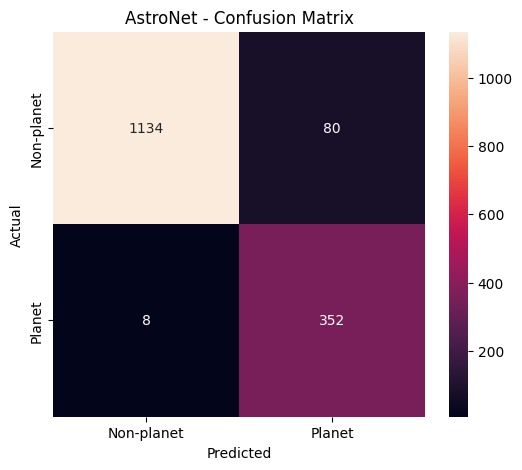

In [61]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

# Calculate F1-score
astronet_f1 = f1_score(
    astronet_y_true,
    astronet_y_pred
)

print("AstroNet F1-score:", round(astronet_f1, 4))

# Detailed classification report
print("\nAstroNet Classification Report:")
print(
    classification_report(
        astronet_y_true,
        astronet_y_pred,
        target_names=["Non-planet", "Planet"]
    )
)

# Calculate confusion matrix
astronet_cm = confusion_matrix(
    astronet_y_true,
    astronet_y_pred
)

print("\nAstroNet Confusion Matrix:")
print(astronet_cm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    astronet_cm,
    annot=True,
    fmt="d",
    xticklabels=["Non-planet", "Planet"],
    yticklabels=["Non-planet", "Planet"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AstroNet - Confusion Matrix")
plt.show()

**45. ROC curve for AstroNet**

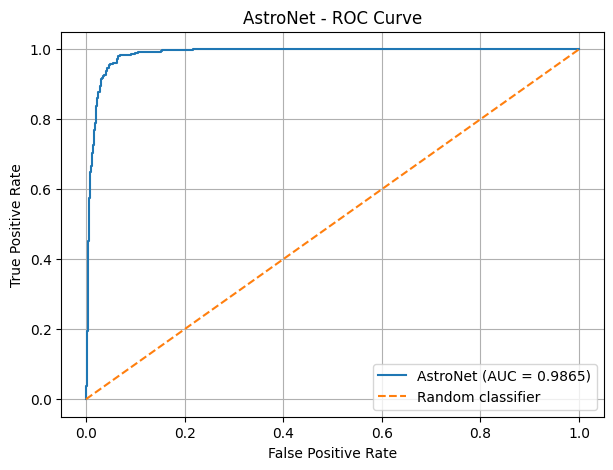

AstroNet ROC-AUC: 0.9865


In [62]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate AstroNet ROC curve
astronet_fpr, astronet_tpr, astronet_thresholds = roc_curve(
    astronet_y_true,
    astronet_y_prob
)

# Calculate AstroNet ROC-AUC
astronet_roc_auc = roc_auc_score(
    astronet_y_true,
    astronet_y_prob
)

# Plot ROC curve
plt.figure(figsize=(7, 5))

plt.plot(
    astronet_fpr,
    astronet_tpr,
    label=f"AstroNet (AUC = {astronet_roc_auc:.4f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AstroNet - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AstroNet ROC-AUC:", round(astronet_roc_auc, 4))

**46. Prepare AstroNet for MC Dropout**

In [63]:
# Find the Dropout layer in AstroNet
for layer in astronet_model.layers:
    if isinstance(layer, tf.keras.layers.Dropout):
        print("Dropout layer found:")
        print("Name:", layer.name)
        print("Rate:", layer.rate)

Dropout layer found:
Name: dropout
Rate: 0.5


**47. Create the MC Dropout function**

In [66]:
def mc_dropout_predict(model, inputs, n_samples=50):
    """
    Perform multiple stochastic predictions using Dropout.
    """

    predictions = []

    for _ in range(n_samples):

        # training=True keeps Dropout active
        prediction = model(
            inputs,
            training=True
        )

        predictions.append(
            prediction.numpy().flatten()
        )

    # Convert all predictions into one NumPy array
    predictions = np.array(predictions)

    return predictions

**48. Run MC Dropout on the test set**

In [67]:
# Store predictions from all 50 MC Dropout passes
mc_predictions = []

# Run through the test dataset
for x_batch, y_batch in astronet_test_dataset:

    # Perform 50 stochastic predictions
    batch_predictions = mc_dropout_predict(
        astronet_model,
        x_batch,
        n_samples=50
    )

    mc_predictions.append(batch_predictions)

# Combine all batches
mc_predictions = np.concatenate(
    mc_predictions,
    axis=1
)

print("MC prediction shape:", mc_predictions.shape)

MC prediction shape: (50, 1574)


**49. Calculate MC Dropout uncertainty**

In [68]:
# Mean prediction across the 50 MC Dropout passes
mc_mean = np.mean(
    mc_predictions,
    axis=0
)

# Standard deviation across the 50 predictions
mc_std = np.std(
    mc_predictions,
    axis=0
)

# Convert mean probabilities into final predictions
mc_pred = (
    mc_mean >= 0.5
).astype(int)

print("Mean prediction shape:", mc_mean.shape)
print("Uncertainty shape:", mc_std.shape)

print("\nExample mean predictions:")
print(mc_mean[:10])

print("\nExample uncertainties:")
print(mc_std[:10])

Mean prediction shape: (1574,)
Uncertainty shape: (1574,)

Example mean predictions:
[8.7285590e-01 1.1591151e-05 4.1351226e-01 3.6284964e-05 8.2136613e-01
 1.4362752e-01 1.8244492e-01 8.1206400e-07 4.7341775e-05 4.8175967e-11]

Example uncertainties:
[4.5005951e-02 3.1400468e-05 7.9643600e-02 4.7131907e-05 7.4175574e-02
 5.2110471e-02 4.7281627e-02 1.3092418e-06 4.7293674e-05 2.9236297e-10]


**50. Analyze uncertainty distribution**

In [69]:
# Basic uncertainty statistics
print("Mean uncertainty:", np.mean(mc_std))
print("Median uncertainty:", np.median(mc_std))
print("Maximum uncertainty:", np.max(mc_std))

# Find the most uncertain examples
most_uncertain_indices = np.argsort(mc_std)[-10:][::-1]

print("\n10 most uncertain test examples:")

for rank, index in enumerate(most_uncertain_indices, start=1):
    print(
        f"{rank}. Index={index}, "
        f"Mean={mc_mean[index]:.4f}, "
        f"Uncertainty={mc_std[index]:.4f}, "
        f"True label={astronet_y_true[index]}"
    )

Mean uncertainty: 0.020481335
Median uncertainty: 0.0037518707
Maximum uncertainty: 0.15270561

10 most uncertain test examples:
1. Index=592, Mean=0.4590, Uncertainty=0.1527, True label=0
2. Index=1343, Mean=0.6879, Uncertainty=0.1497, True label=1
3. Index=459, Mean=0.2419, Uncertainty=0.1438, True label=0
4. Index=1119, Mean=0.4503, Uncertainty=0.1420, True label=0
5. Index=1521, Mean=0.3473, Uncertainty=0.1394, True label=0
6. Index=407, Mean=0.4586, Uncertainty=0.1276, True label=1
7. Index=79, Mean=0.1799, Uncertainty=0.1276, True label=0
8. Index=1331, Mean=0.4451, Uncertainty=0.1269, True label=0
9. Index=587, Mean=0.7307, Uncertainty=0.1239, True label=0
10. Index=456, Mean=0.3368, Uncertainty=0.1231, True label=0


**51. Visualize uncertainty distribution**

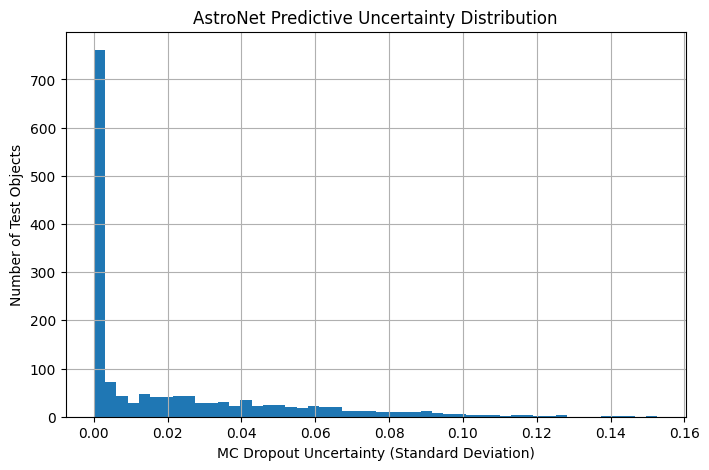

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(
    mc_std,
    bins=50
)

plt.xlabel("MC Dropout Uncertainty (Standard Deviation)")
plt.ylabel("Number of Test Objects")
plt.title("AstroNet Predictive Uncertainty Distribution")

plt.grid(True)
plt.show()

**52. Confidence vs. Uncertainty**

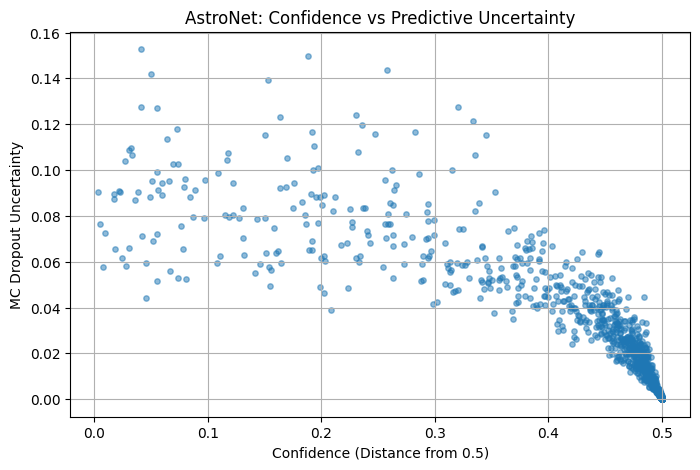

In [71]:
# Confidence = distance from the 0.5 decision boundary
confidence = np.abs(
    mc_mean - 0.5
)

# Plot confidence against uncertainty
plt.figure(figsize=(8, 5))

plt.scatter(
    confidence,
    mc_std,
    alpha=0.5,
    s=15
)

plt.xlabel("Confidence (Distance from 0.5)")
plt.ylabel("MC Dropout Uncertainty")
plt.title("AstroNet: Confidence vs Predictive Uncertainty")

plt.grid(True)
plt.show()

**53. Quantify the relationship**

In [72]:
from scipy.stats import spearmanr

# Calculate Spearman correlation
correlation, p_value = spearmanr(
    confidence,
    mc_std
)

print("Spearman correlation:", round(correlation, 4))
print("p-value:", p_value)

Spearman correlation: -0.9921
p-value: 0.0


**54. Extract the most uncertain light curves**

In [73]:
# Store test light curves for case-study analysis
test_global_curves = []
test_local_curves = []
test_labels = []

# Read the test dataset again
case_dataset = tf.data.TFRecordDataset(test_files)

# Parse the examples
case_dataset = case_dataset.map(
    parse_example,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Collect the light curves
for inputs, label, known in case_dataset:

    # Skip unknown labels
    if not known.numpy():
        continue

    test_global_curves.append(
        inputs[0].numpy().squeeze()
    )

    test_local_curves.append(
        inputs[1].numpy().squeeze()
    )

    test_labels.append(
        label.numpy()
    )

# Convert to NumPy arrays
test_global_curves = np.array(test_global_curves)
test_local_curves = np.array(test_local_curves)
test_labels = np.array(test_labels)

print("Global curves:", test_global_curves.shape)
print("Local curves :", test_local_curves.shape)
print("Labels       :", test_labels.shape)

Global curves: (1574, 2001)
Local curves : (1574, 201)
Labels       : (1574,)


**55. Plot the most uncertain case**

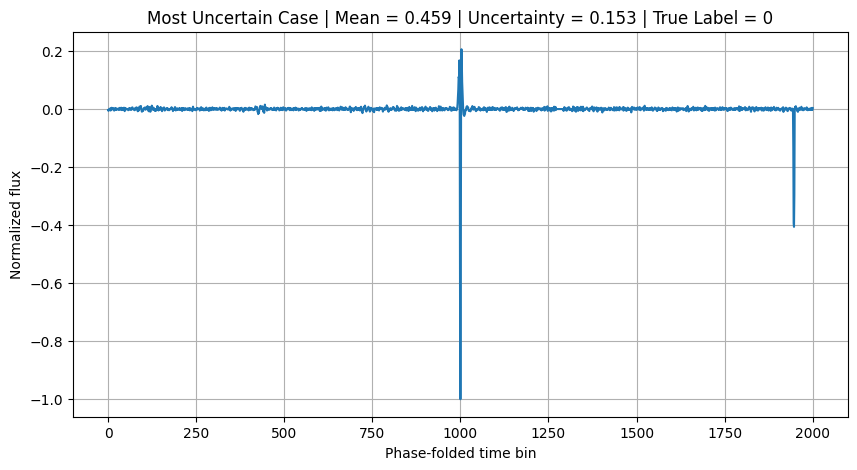

In [74]:
# Select the most uncertain test object
idx = most_uncertain_indices[0]

# Create one figure
plt.figure(figsize=(10, 5))

# Plot the global light curve
plt.plot(
    test_global_curves[idx]
)

# Add the prediction information
plt.title(
    f"Most Uncertain Case | "
    f"Mean = {mc_mean[idx]:.3f} | "
    f"Uncertainty = {mc_std[idx]:.3f} | "
    f"True Label = {test_labels[idx]}"
)

plt.xlabel("Phase-folded time bin")
plt.ylabel("Normalized flux")

plt.grid(True)
plt.show()

**56. Plot the local view of the most uncertain case**

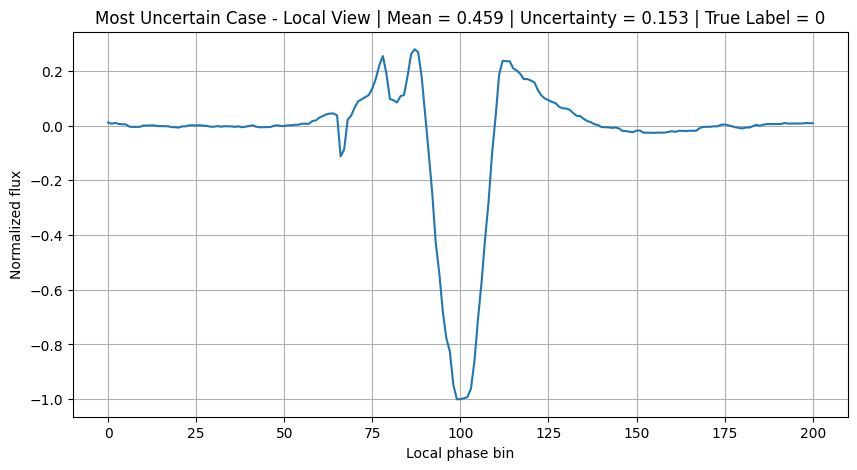

In [75]:
# Create a figure for the local view
plt.figure(figsize=(10, 5))

# Plot the zoomed transit region
plt.plot(
    test_local_curves[idx]
)

# Add prediction information
plt.title(
    f"Most Uncertain Case - Local View | "
    f"Mean = {mc_mean[idx]:.3f} | "
    f"Uncertainty = {mc_std[idx]:.3f} | "
    f"True Label = {test_labels[idx]}"
)

plt.xlabel("Local phase bin")
plt.ylabel("Normalized flux")

plt.grid(True)
plt.show()

**57. Visualize the 50 MC Dropout predictions**

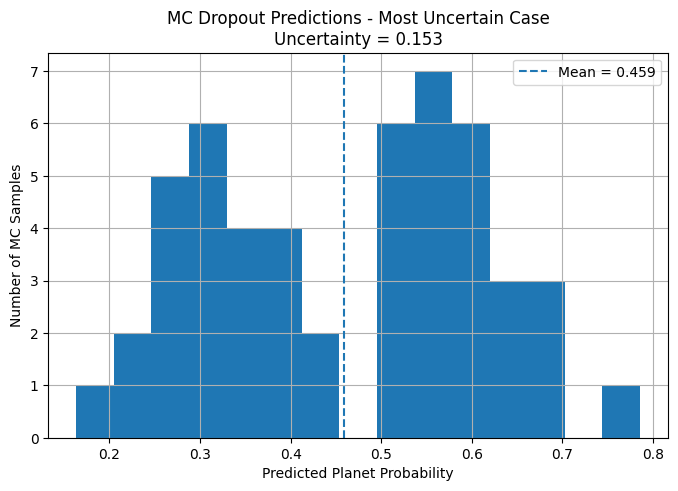

Minimum prediction: 0.1634
Maximum prediction: 0.7857
Mean prediction: 0.459
Standard deviation: 0.1527


In [76]:
# Get the 50 stochastic predictions for the most uncertain object
case_predictions = mc_predictions[:, idx]

# Plot the prediction distribution
plt.figure(figsize=(8, 5))

plt.hist(
    case_predictions,
    bins=15
)

# Show the mean prediction
plt.axvline(
    mc_mean[idx],
    linestyle="--",
    label=f"Mean = {mc_mean[idx]:.3f}"
)

plt.xlabel("Predicted Planet Probability")
plt.ylabel("Number of MC Samples")
plt.title(
    f"MC Dropout Predictions - Most Uncertain Case\n"
    f"Uncertainty = {mc_std[idx]:.3f}"
)

plt.legend()
plt.grid(True)
plt.show()

print("Minimum prediction:", round(case_predictions.min(), 4))
print("Maximum prediction:", round(case_predictions.max(), 4))
print("Mean prediction:", round(case_predictions.mean(), 4))
print("Standard deviation:", round(case_predictions.std(), 4))

**58. Identify AstroNet convolutional layers**

In [77]:
# Find all Conv1D layers in AstroNet
print("AstroNet Conv1D layers:\n")

for layer in astronet_model.layers:
    if isinstance(layer, tf.keras.layers.Conv1D):
        print(
            layer.name,
            "→ output shape:",
            layer.output.shape
        )

AstroNet Conv1D layers:

conv1d_3 → output shape: (None, 1997, 16)
conv1d_4 → output shape: (None, 993, 32)
conv1d_5 → output shape: (None, 491, 64)
conv1d_6 → output shape: (None, 240, 128)
conv1d_8 → output shape: (None, 197, 16)
conv1d_7 → output shape: (None, 114, 256)
conv1d_9 → output shape: (None, 92, 32)


**59. Build the Grad-CAM model**

In [78]:
# Get the final convolutional layers
global_conv_layer = astronet_model.get_layer("conv1d_7")
local_conv_layer = astronet_model.get_layer("conv1d_9")

# Create a model that returns:
# 1. Global feature maps
# 2. Local feature maps
# 3. Final prediction
gradcam_model = tf.keras.Model(
    inputs=astronet_model.inputs,
    outputs=[
        global_conv_layer.output,
        local_conv_layer.output,
        astronet_model.output
    ],
    name="AstroNet_GradCAM"
)

print("Grad-CAM model created.")
print("Global feature maps:", global_conv_layer.output.shape)
print("Local feature maps :", local_conv_layer.output.shape)
print("Prediction shape   :", astronet_model.output.shape)

Grad-CAM model created.
Global feature maps: (None, 114, 256)
Local feature maps : (None, 92, 32)
Prediction shape   : (None, 1)


**60. Create the 1D Grad-CAM function**

In [80]:
def compute_gradcam(model, inputs, layer_name):
    """
    Compute 1D Grad-CAM for a selected convolutional layer.
    """

    # Get the convolutional layer
    conv_layer = model.get_layer(layer_name)

    # Create a model that returns feature maps and prediction
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[
            conv_layer.output,
            model.output
        ]
    )

    # Record gradients
    with tf.GradientTape() as tape:

        # Get feature maps and prediction
        conv_output, prediction = grad_model(inputs)

        # Use the planet probability as the target
        target = prediction[:, 0]

    # Calculate gradients of prediction
    # with respect to convolutional feature maps
    gradients = tape.gradient(
        target,
        conv_output
    )

    # Average gradients across the time dimension
    weights = tf.reduce_mean(
        gradients,
        axis=1
    )

    # Combine feature maps using gradient weights
    cam = tf.reduce_sum(
        conv_output * tf.expand_dims(weights, axis=1),
        axis=-1
    )

    # Keep only positive importance
    cam = tf.maximum(
        cam,
        0
    )

    # Normalize between 0 and 1
    cam = cam / (
        tf.reduce_max(
            cam,
            axis=1,
            keepdims=True
        ) + 1e-8
    )

    return cam.numpy(), prediction.numpy()

**61. Apply Grad-CAM to the most uncertain case**

In [81]:
# Prepare the selected light curve as a batch
global_case = test_global_curves[idx][np.newaxis, :, np.newaxis]
local_case = test_local_curves[idx][np.newaxis, :, np.newaxis]

# Calculate global Grad-CAM
global_cam, gradcam_prediction = compute_gradcam(
    astronet_model,
    {
        "global_input": global_case,
        "local_input": local_case
    },
    "conv1d_7"
)

# Calculate local Grad-CAM
local_cam, _ = compute_gradcam(
    astronet_model,
    {
        "global_input": global_case,
        "local_input": local_case
    },
    "conv1d_9"
)

print("Global Grad-CAM shape:", global_cam.shape)
print("Local Grad-CAM shape :", local_cam.shape)
print("Model prediction     :", gradcam_prediction[0][0])

Global Grad-CAM shape: (1, 114)
Local Grad-CAM shape : (1, 92)
Model prediction     : 0.45128682


**62. Resize Grad-CAM and overlay it on the light curves**

In [82]:
# Remove the batch dimension
global_cam_1d = global_cam[0]
local_cam_1d = local_cam[0]

# Resize Grad-CAM to match the original light-curve lengths
global_cam_resized = np.interp(
    np.linspace(0, len(global_cam_1d) - 1, 2001),
    np.arange(len(global_cam_1d)),
    global_cam_1d
)

local_cam_resized = np.interp(
    np.linspace(0, len(local_cam_1d) - 1, 201),
    np.arange(len(local_cam_1d)),
    local_cam_1d
)

print("Resized global CAM:", global_cam_resized.shape)
print("Resized local CAM :", local_cam_resized.shape)

Resized global CAM: (2001,)
Resized local CAM : (201,)


**63. Plot Grad-CAM explanations**

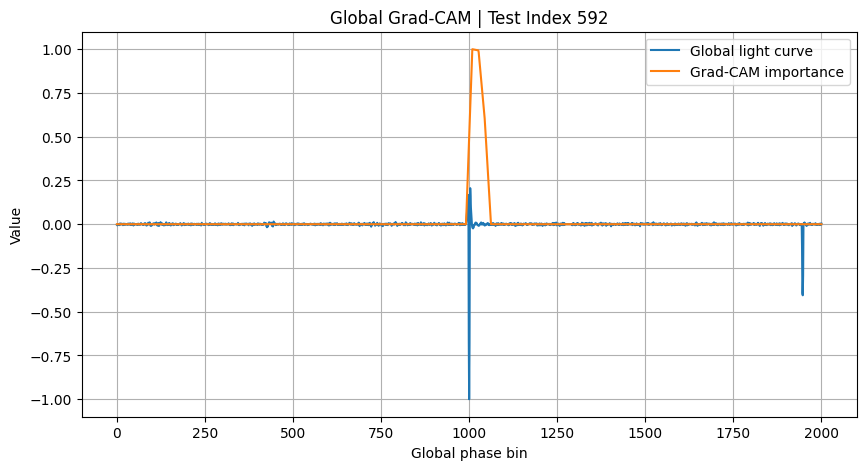

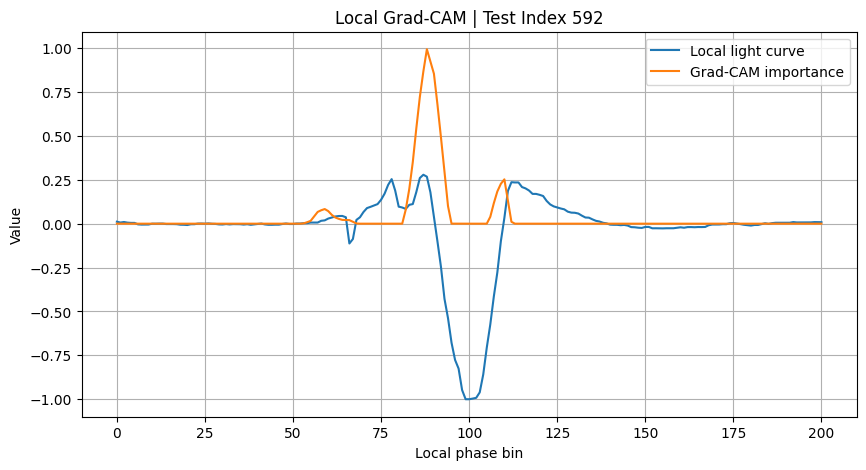

In [83]:
# Create the global Grad-CAM plot
plt.figure(figsize=(10, 5))

plt.plot(
    test_global_curves[idx],
    label="Global light curve"
)

plt.plot(
    global_cam_resized,
    label="Grad-CAM importance"
)

plt.xlabel("Global phase bin")
plt.ylabel("Value")
plt.title(
    f"Global Grad-CAM | Test Index {idx}"
)

plt.legend()
plt.grid(True)
plt.show()


# Create the local Grad-CAM plot
plt.figure(figsize=(10, 5))

plt.plot(
    test_local_curves[idx],
    label="Local light curve"
)

plt.plot(
    local_cam_resized,
    label="Grad-CAM importance"
)

plt.xlabel("Local phase bin")
plt.ylabel("Value")
plt.title(
    f"Local Grad-CAM | Test Index {idx}"
)

plt.legend()
plt.grid(True)
plt.show()

**64. Calibration analysis**

In [84]:
from sklearn.metrics import brier_score_loss

# Calculate Brier score for AstroNet
brier_score = brier_score_loss(
    astronet_y_true,
    astronet_y_prob
)

print("AstroNet Brier score:", round(brier_score, 4))

AstroNet Brier score: 0.0441


**65. Calibration curve**

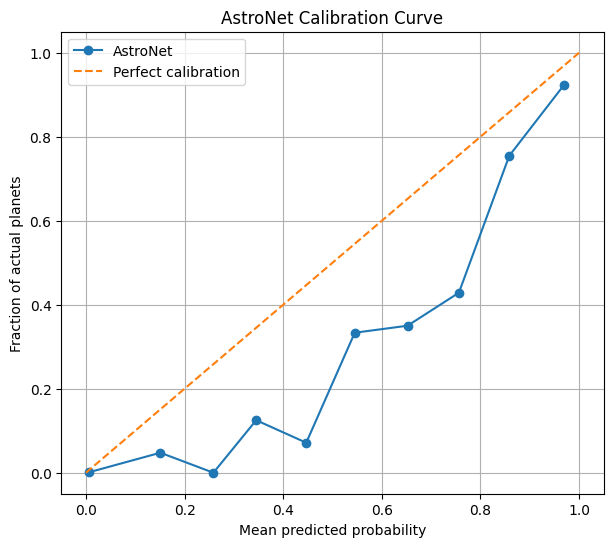

In [85]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Calculate calibration values
prob_true, prob_pred = calibration_curve(
    astronet_y_true,
    astronet_y_prob,
    n_bins=10,
    strategy="uniform"
)

# Plot calibration curve
plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="AstroNet"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of actual planets")
plt.title("AstroNet Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

**66. Final model comparison**

In [86]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Baseline 1D CNN": [
        0.9161,
        0.7446,
        0.9639,
        0.8402,
        0.9781
    ],
    "AstroNet": [
        0.9441,
        0.8149,
        0.9778,
        0.8889,
        0.9865
    ]
})

comparison["Improvement"] = (
    comparison["AstroNet"] - comparison["Baseline 1D CNN"]
)

display(comparison)

,Metric,Baseline 1D CNN,AstroNet,Improvement
0,Accuracy,0.9161,0.9441,0.0280
1,Precision,0.7446,0.8149,0.0703
2,Recall,0.9639,0.9778,0.0139
3,F1 Score,0.8402,0.8889,0.0487
4,ROC-AUC,0.9781,0.9865,0.0084


**67. Final case-study summary**

In [87]:
case_indices = [592, 1343, 587]

case_study = pd.DataFrame({
    "Test Index": case_indices,
    "True Label": [
        y_true[i] for i in case_indices
    ],
    "MC Mean Probability": [
        mc_mean[i] for i in case_indices
    ],
    "MC Uncertainty (Std)": [
        mc_std[i] for i in case_indices
    ],
    "MC Prediction": [
        mc_pred[i] for i in case_indices
    ]
})

case_study["Confidence"] = abs(
    case_study["MC Mean Probability"] - 0.5
)

display(case_study)

,Test Index,True Label,MC Mean Probability,MC Uncertainty (Std),MC Prediction,Confidence
0,592,0,0.458959,0.152706,0,0.041041
1,1343,1,0.687944,0.149684,1,0.187944
2,587,0,0.730666,0.123910,1,0.230666


**68. Save the trained models**

In [88]:
import os

save_dir = "/content/drive/MyDrive/AstroNet/results"
os.makedirs(save_dir, exist_ok=True)

# Save models
baseline_model.save(
    os.path.join(save_dir, "baseline_1d_cnn.keras")
)

astronet_model.save(
    os.path.join(save_dir, "astronet_dual_input.keras")
)

print("Models saved successfully!")
print("Saved to:", save_dir)

Models saved successfully!
Saved to: /content/drive/MyDrive/AstroNet/results


**69. Save all results**

In [89]:
# Save predictions and uncertainty results

results_path = "/content/drive/MyDrive/AstroNet/results"

np.savez(
    os.path.join(results_path, "astronet_test_results.npz"),

    # Ground-truth labels
    y_true=astronet_y_true,

    # Deterministic AstroNet predictions
    y_prob=astronet_y_prob,
    y_pred=astronet_y_pred,

    # MC Dropout results
    mc_mean=mc_mean,
    mc_std=mc_std,
    mc_pred=mc_pred,

    # Baseline predictions
    baseline_y_true=y_true,
    baseline_y_prob=y_prob,
    baseline_y_pred=y_pred
)

# Save comparison table
comparison.to_csv(
    os.path.join(results_path, "model_comparison.csv"),
    index=False
)

# Save case-study table
case_study.to_csv(
    os.path.join(results_path, "case_studies.csv"),
    index=False
)

print("All results saved successfully!")
print("\nFiles:")
print("1. astronet_test_results.npz")
print("2. model_comparison.csv")
print("3. case_studies.csv")

All results saved successfully!

Files:
1. astronet_test_results.npz
2. model_comparison.csv
3. case_studies.csv


**70. Create the project README**

In [90]:
readme_path = "/content/drive/MyDrive/AstroNet/results/README.md"

readme_content = """
# Deep Learning Exoplanet Vetting from Time-Series Photometry

## Project Overview

This project investigates the use of deep learning for exoplanet vetting from
Kepler time-series photometry.

The project implements:

1. A baseline single-input 1D CNN
2. An AstroNet-style dual-input CNN using global and local views
3. Monte Carlo Dropout for predictive uncertainty estimation
4. Grad-CAM explainability for identifying important regions of the light curve
5. Calibration analysis
6. Comparative evaluation using standard classification metrics

The main objective is to determine whether combining global and local views of
a phase-folded light curve improves exoplanet candidate classification.

---

## Dataset

The main dataset is the precomputed Kepler dataset used for the AstroNet-style
experiment.

Each example contains:

- Global view: 2001 flux measurements
- Local view: 201 flux measurements
- Transit-related metadata
- AstroNet training-set label

Labels were converted to binary classification:

- PC -> 1 (Planet Candidate)
- AFP -> 0 (False Positive)
- NTP -> 0 (False Positive)

The training data contained:

- PC: 2,885
- AFP: 7,643
- NTP: 2,061
- Total: 12,589

Because the classes are imbalanced, class weights were used during training.

---

## Model Architecture

### Baseline 1D CNN

The baseline model uses only the global light-curve view.

Architecture:

Global Input
-> Conv1D(16)
-> MaxPooling
-> Conv1D(32)
-> MaxPooling
-> Conv1D(64)
-> MaxPooling
-> Flatten
-> Dense(64)
-> Sigmoid Output

Total parameters: approximately 1.01 million.

---

### AstroNet-Style Dual-Input CNN

The AstroNet-style model processes both global and local views.

### Global branch

Conv1D layers:

16 -> 32 -> 64 -> 128 -> 256 filters

Each convolution is followed by max pooling.

### Local branch

Conv1D layers:

16 -> 32 filters

Each convolution is followed by max pooling.

The extracted representations are concatenated and passed through:

Concatenation
-> Dense(512)
-> Dropout(0.5)
-> Sigmoid Output

Total parameters: approximately 8.14 million.

This implementation follows the global/local-view design of AstroNet,
but should be described as an AstroNet-style implementation rather than an
exact reproduction of the original research implementation.

---

## Training

Framework:

- TensorFlow / Keras
- GPU acceleration
- Adam optimizer
- Learning rate: 0.001
- Binary cross-entropy loss
- Batch size: 64
- Training epochs: 10
- Class weighting for imbalance

---

## Results

### Baseline vs AstroNet

| Metric | Baseline 1D CNN | AstroNet |
|---|---:|---:|
| Accuracy | 91.61% | **94.41%** |
| Precision | 74.46% | **81.49%** |
| Recall | 96.39% | **97.78%** |
| F1 Score | 84.02% | **88.89%** |
| ROC-AUC | 97.81% | **98.65%** |

AstroNet improved every evaluated metric.

The largest improvement was in precision, increasing by
approximately 7.03 percentage points.

---

## Confusion Matrices

### Baseline

[[1095, 119],
 [  13, 347]]

### AstroNet

[[1134,  80],
 [   8, 352]]

The AstroNet-style model reduced false positives from 119 to 80 and
false negatives from 13 to 8.

---

## Monte Carlo Dropout Uncertainty

Monte Carlo Dropout was performed using 50 stochastic forward passes.

For each test example:

- Mean prediction = average of 50 predictions
- Uncertainty = standard deviation of 50 predictions

Overall uncertainty statistics:

- Mean uncertainty: approximately 0.0205
- Median uncertainty: approximately 0.00375
- Maximum uncertainty: approximately 0.1527

High uncertainty indicates stronger variation between stochastic model
predictions and can therefore highlight ambiguous examples.

---

## Case Studies

### Test Index 592

- True label: Non-planet
- MC mean probability: 0.459
- MC uncertainty: 0.153
- MC prediction: Non-planet

This is a highly ambiguous example because its predicted probability is
close to the 0.5 decision threshold and its MC Dropout uncertainty is high.

Grad-CAM also shows strong attention around the transit-like event.

---

### Test Index 1343

- True label: Planet
- MC mean probability: 0.688
- MC uncertainty: 0.150
- MC prediction: Planet

The model correctly classifies this example, but the relatively high
uncertainty indicates that the prediction is not completely stable across
stochastic forward passes.

---

### Test Index 587

- True label: Non-planet
- MC mean probability: 0.731
- MC uncertainty: 0.124
- MC prediction: Planet

This example represents a difficult misclassification where the model
assigns a relatively high probability to the planet class despite the
true label being non-planet.

---

## Explainability

1D Grad-CAM was applied to the final convolutional layers of both the global
and local branches.

The resulting importance maps identify regions of the light curve that
contribute strongly to the model prediction.

For Test Index 592, the strongest Grad-CAM activations occur around the
central transit-like event in both the global and local views.

---

## Calibration

AstroNet Brier score:

**0.0441**

The calibration curve shows that the model is not perfectly calibrated and
tends to be overconfident in parts of the intermediate-to-high probability
range.

---

## Key Findings

1. The AstroNet-style dual-input architecture outperformed the simpler
   global-only CNN across all major evaluation metrics.

2. Combining global and local views improved precision substantially.

3. The model achieved a ROC-AUC of approximately 98.65%.

4. Monte Carlo Dropout provided an additional measure of predictive
   uncertainty and highlighted difficult examples.

5. Grad-CAM provided an interpretable view of which regions of the light
   curves influenced predictions.

6. Calibration analysis showed that strong classification performance does
   not necessarily imply perfectly calibrated probabilities.

---

## Saved Results

The following files are stored in the `results` directory:

- `baseline_1d_cnn.keras`
- `astronet_dual_input.keras`
- `astronet_test_results.npz`
- `model_comparison.csv`
- `case_studies.csv`

---

## Technologies

- Python
- TensorFlow
- Keras
- NumPy
- Pandas
- Scikit-learn
- Matplotlib
- Google Colab
- Kepler photometric data

---

## Project Scope

This project demonstrates an end-to-end deep-learning workflow for
exoplanet candidate vetting, including classification, uncertainty
estimation, explainability, and calibration analysis.
"""

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README created successfully!")
print("Saved to:", readme_path)

README created successfully!
Saved to: /content/drive/MyDrive/AstroNet/results/README.md


**71. Final sanity check**

In [92]:
import os

results_path = "/content/drive/MyDrive/AstroNet/results"

expected_files = [
    "baseline_1d_cnn.keras",
    "astronet_dual_input.keras",
    "astronet_test_results.npz",
    "model_comparison.csv",
    "case_studies.csv",
    "README.md"
]

print("Final Results Check\n")

all_present = True

for filename in expected_files:
    path = os.path.join(results_path, filename)
    exists = os.path.exists(path)

    print(f"{'✓' if exists else '✗'} {filename}")

    if not exists:
        all_present = False

print("\n" + ("ALL FILES PRESENT" if all_present else "SOME FILES ARE MISSING"))

Final Results Check

✓ baseline_1d_cnn.keras
✓ astronet_dual_input.keras
✓ astronet_test_results.npz
✓ model_comparison.csv
✓ case_studies.csv
✓ README.md

ALL FILES PRESENT
